# QISKIT Fall Fest IIT Roorkee Quantum Computing Group

#Team Entangled Innovators

Mandalia Keval Rajeshbhai
25123016
BTech Electrical Engineering (2025 - 2029)

Abhirup Mahato (2511001) {hehe, he is just a placeholder}

# Quantum Neural ODEs for Chaotic Environments
### *How much quantum memory does it take to imitate a chaotic environment?*

**Qiskit Fall Fest project.** One "bell" qubit sits inside a "room" of other qubits.
We record how the bell's state (its Bloch arrow) changes over time, then train a tiny
"fake room" — a few helper qubits with tunable knobs — to reproduce the same behaviour.

In [ ]:
!pip install -q qiskit==2.5.2 qiskit-aer==0.17.2 qiskit-ibm-runtime==0.50.0

In [ ]:
from dataclasses import dataclass, replace
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, __version__ as qiskit_version
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector

print("qiskit", qiskit_version, "| numpy", np.__version__)

qiskit 2.5.2 | numpy 2.4.4


## 1. The real room

**Qubit layout:** qubit `0` is the **bell** (the only one we listen to); qubits `1 … N` are the **room**.

**The rule that drives everything (the Hamiltonian):**

$$H = g\,Z_0 Z_1 \;+\; J\sum_{i=1}^{N-1} Z_i Z_{i+1} \;+\; \sum_{i=0}^{N}\big(h_x X_i + h_z Z_i\big)$$

- $g$ — how strongly the bell talks to the room (how fast it leaks information)
- $J$ — how strongly room qubits talk to each other
- $h_x, h_z$ — magnetic fields. **$h_z$ is the chaos knob:**
  - $h_z = 0$ → **simple room** (information echoes back)
  - $h_z \neq 0$ → **chaotic room** (information gets scrambled)

The values $h_x = 0.9045,\ h_z = 0.8090$ are a standard strongly-chaotic choice **[1]**.
Choosing $g \neq J$ also breaks the chain's mirror symmetry, which the chaos test in Part 4 needs.

In [ ]:
@dataclass(frozen=True)
class RoomParams:
    n_room: int = 5        # number of room qubits
    J: float = 1.0         # room-room coupling
    g: float = 0.5         # bell-room coupling
    hx: float = 0.9045     # transverse field
    hz: float = 0.8090     # longitudinal field = chaos knob

    @property
    def n_qubits(self):
        return self.n_room + 1


CHAOTIC = RoomParams()
SIMPLE = replace(CHAOTIC, hz=0.0)   # same room, chaos knob off
ROOMS = {"simple": SIMPLE, "chaotic": CHAOTIC}
COLORS = {"simple": "tab:blue", "chaotic": "tab:red"}


def hamiltonian(p: RoomParams) -> SparsePauliOp:
    n = p.n_qubits
    terms = [("ZZ", [0, 1], p.g)]
    terms += [("ZZ", [i, i + 1], p.J) for i in range(1, n - 1)]
    terms += [("X", [i], p.hx) for i in range(n)]
    if p.hz:
        terms += [("Z", [i], p.hz) for i in range(n)]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=n).simplify()


def bell_observables(n_qubits):
    # X, Y, Z on the bell -> the three components of its arrow (Bloch vector)
    return [SparsePauliOp.from_sparse_list([(P, [0], 1.0)], n_qubits) for P in "XYZ"]


print(hamiltonian(SIMPLE))

SparsePauliOp(['IIIIZZ', 'IIIZZI', 'IIZZII', 'IZZIII', 'ZZIIII', 'IIIIIX', 'IIIIXI', 'IIIXII', 'IIXIII', 'IXIIII', 'XIIIII'],
              coeffs=[0.5   +0.j, 1.    +0.j, 1.    +0.j, 1.    +0.j, 1.    +0.j, 0.9045+0.j,
 0.9045+0.j, 0.9045+0.j, 0.9045+0.j, 0.9045+0.j, 0.9045+0.j])


## 2. Starting states

- **Bell:** pointed in one of 6 directions (±x, ±y, ±z on the Bloch sphere).
- **Room:** every qubit starts in $|{+y}\rangle$. These states have $\langle X\rangle=\langle Y\rangle=\langle Z\rangle=0$,
  so the room carries **no information of its own** and has roughly zero energy — the regime where chaos scrambles fastest.

In [ ]:
# (theta, phi) on the Bloch sphere for each starting direction of the bell
BELL_DIRS = {
    "+z": (0.0, 0.0),             "-z": (np.pi, 0.0),
    "+x": (np.pi / 2, 0.0),       "-x": (np.pi / 2, np.pi),
    "+y": (np.pi / 2, np.pi / 2), "-y": (np.pi / 2, -np.pi / 2),
}


def prep_circuit(p: RoomParams, bell_dir: str) -> QuantumCircuit:
    qc = QuantumCircuit(p.n_qubits)
    theta, phi = BELL_DIRS[bell_dir]
    qc.ry(theta, 0)
    qc.rz(phi, 0)
    for q in range(1, p.n_qubits):   # room qubits -> |+y>
        qc.h(q)
        qc.s(q)
    return qc


print(prep_circuit(SIMPLE, "+x").draw(fold=-1))

     ┌─────────┐┌───────┐
q_0: ┤ Ry(π/2) ├┤ Rz(0) ├
     └──┬───┬──┘└─┬───┬─┘
q_1: ───┤ H ├─────┤ S ├──
        ├───┤     ├───┤  
q_2: ───┤ H ├─────┤ S ├──
        ├───┤     ├───┤  
q_3: ───┤ H ├─────┤ S ├──
        ├───┤     ├───┤  
q_4: ───┤ H ├─────┤ S ├──
        ├───┤     ├───┤  
q_5: ───┤ H ├─────┤ S ├──
        └───┘     └───┘  


## 3. Two ways to simulate the room

**(a) Exact (ground truth).** Diagonalise $H$ once, then $|\psi(t)\rangle = V e^{-iEt} V^\dagger |\psi(0)\rangle$ for any time.

**(b) Quantum circuits (Trotter steps).** A quantum computer can't apply $e^{-iHt}$ in one go, so we chop time into small
steps $dt$ and apply each piece of $H$ as gates. We use the symmetric (2nd-order) Suzuki–Trotter formula **[2]**:

$$e^{-iH\,dt} \approx e^{-iH_X dt/2}\; e^{-i(H_{ZZ}+H_Z)\,dt}\; e^{-iH_X dt/2}$$

Gate conventions in Qiskit: `rx(a)` $=e^{-iaX/2}$, `rzz(a)` $=e^{-iaZZ/2}$, so a term $c\,ZZ$ for time $dt$ is `rzz(2*c*dt)`.

`trotter_trajectory` takes any **EstimatorV2**. Today it's the exact `StatevectorEstimator`; in Part 8 we swap in IBM's
hardware estimator **[14]** **without changing anything else**.

In [ ]:
@lru_cache(maxsize=None)
def _eig(p: RoomParams):
    return np.linalg.eigh(hamiltonian(p).to_matrix())


def exact_trajectory(p: RoomParams, bell_dir: str, times) -> np.ndarray:
    # Bell arrow r(t) at each time. Shape (len(times), 3).
    E, V = _eig(p)
    c = V.conj().T @ Statevector(prep_circuit(p, bell_dir)).data
    obs = [o.to_matrix() for o in bell_observables(p.n_qubits)]
    psi_t = V @ (np.exp(-1j * np.outer(E, times)) * c[:, None])
    return np.stack(
        [np.real(np.einsum("it,ij,jt->t", psi_t.conj(), O, psi_t)) for O in obs], axis=1
    )


def trotter_step(p: RoomParams, dt: float) -> QuantumCircuit:
    n = p.n_qubits
    qc = QuantumCircuit(n, name="U(dt)")
    for q in range(n):
        qc.rx(p.hx * dt, q)                          # half step of X field
    bonds = [(0, 1, p.g)] + [(i, i + 1, p.J) for i in range(1, n - 1)]
    for parity in (0, 1):                            # even bonds, then odd bonds
        for a, b, c in bonds:
            if a % 2 == parity:
                qc.rzz(2 * c * dt, a, b)
    if p.hz:
        for q in range(n):
            qc.rz(2 * p.hz * dt, q)
    for q in range(n):
        qc.rx(p.hx * dt, q)                          # second half step
    return qc


def trotter_circuit(p, bell_dir, steps, dt):
    qc = prep_circuit(p, bell_dir)
    step = trotter_step(p, dt)
    for _ in range(steps):
        qc.compose(step, inplace=True)
    return qc


def trotter_trajectory(p, bell_dir, n_steps, dt, estimator=None) -> np.ndarray:
    # Bell arrow after 0..n_steps Trotter steps. Shape (n_steps+1, 3).
    estimator = estimator or StatevectorEstimator()
    obs = bell_observables(p.n_qubits)
    pubs = [(trotter_circuit(p, bell_dir, k, dt), obs) for k in range(n_steps + 1)]
    return np.array([r.data.evs for r in estimator.run(pubs).result()])


print("One Trotter step for the chaotic room:")
print(trotter_step(CHAOTIC, 0.1).draw(fold=-1))

One Trotter step for the chaotic room:
     ┌─────────────┐          ┌────────────┐┌─────────────┐               
q_0: ┤ Rx(0.09045) ├─■────────┤ Rz(0.1618) ├┤ Rx(0.09045) ├───────────────
     ├─────────────┤ │ZZ(0.1) └────────────┘└┬────────────┤┌─────────────┐
q_1: ┤ Rx(0.09045) ├─■───────────■───────────┤ Rz(0.1618) ├┤ Rx(0.09045) ├
     ├─────────────┤             │ZZ(0.2)    ├────────────┤├─────────────┤
q_2: ┤ Rx(0.09045) ├─■───────────■───────────┤ Rz(0.1618) ├┤ Rx(0.09045) ├
     ├─────────────┤ │ZZ(0.2)                ├────────────┤├─────────────┤
q_3: ┤ Rx(0.09045) ├─■───────────■───────────┤ Rz(0.1618) ├┤ Rx(0.09045) ├
     ├─────────────┤             │ZZ(0.2)    ├────────────┤├─────────────┤
q_4: ┤ Rx(0.09045) ├─■───────────■───────────┤ Rz(0.1618) ├┤ Rx(0.09045) ├
     ├─────────────┤ │ZZ(0.2) ┌────────────┐┌┴────────────┤└─────────────┘
q_5: ┤ Rx(0.09045) ├─■────────┤ Rz(0.1618) ├┤ Rx(0.09045) ├───────────────
     └─────────────┘          └────────────┘└─────────────┘  

### Choosing the time step $dt$
Smaller $dt$ = more accurate but deeper circuits. Trotter error should shrink like $dt^2$.

In [ ]:
print(f"{'room':<8} {'dt':>5} {'max error up to t=10':>22}")
for name, p in ROOMS.items():
    for dt in (0.25, 0.1):
        n = int(round(10 / dt))
        tr = trotter_trajectory(p, "+z", n, dt)
        ex = exact_trajectory(p, "+z", np.arange(n + 1) * dt)
        print(f"{name:<8} {dt:>5} {np.abs(tr - ex).max():>22.3f}")

room        dt   max error up to t=10


simple    0.25                  0.212


simple     0.1                  0.033


chaotic   0.25                  0.047


chaotic    0.1                  0.007


**Observation:** the *simple* room is much more sensitive to Trotter error than the chaotic one. Echoes rely on precise timing,
so small phase errors pile up; chaos washes them out. We use **$dt = 0.1$** from here on.

## 4. Experiment: does information come back to the bell?

We track the **arrow length** $|\vec r(t)|$, averaged over the 6 starting directions.
Length 1 = the bell holds all its information; shorter = information has leaked into the room.

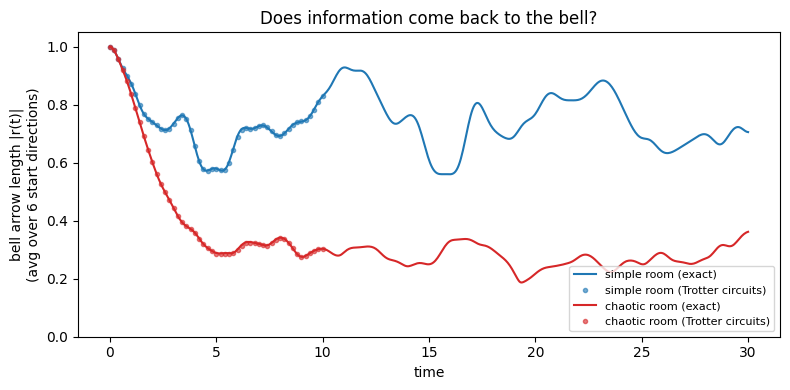

In [ ]:
T_MAX, DT_FINE = 30.0, 0.05
DT_TROT, N_TROT = 0.1, 100

t_fine = np.arange(0, T_MAX + 1e-9, DT_FINE)
t_trot = np.arange(N_TROT + 1) * DT_TROT

data, summary = {"times": t_fine}, {}
fig, ax = plt.subplots(figsize=(8, 4))
for name, p in ROOMS.items():
    traj = np.stack([exact_trajectory(p, d, t_fine) for d in BELL_DIRS])   # (6, T, 3)
    data[name] = traj
    length = np.linalg.norm(traj, axis=2).mean(axis=0)
    ax.plot(t_fine, length, color=COLORS[name], label=f"{name} room (exact)")

    tr = np.stack([trotter_trajectory(p, d, N_TROT, DT_TROT) for d in BELL_DIRS])
    ex = np.stack([exact_trajectory(p, d, t_trot) for d in BELL_DIRS])
    ax.plot(t_trot[::2], np.linalg.norm(tr, axis=2).mean(axis=0)[::2], "o", ms=3,
            color=COLORS[name], alpha=0.6, label=f"{name} room (Trotter circuits)")
    late = length[t_fine > 5]
    summary[name] = (late.min(), late.max(), np.abs(tr - ex).max())

ax.set(xlabel="time", ylabel="bell arrow length |r(t)|\n(avg over 6 start directions)",
       ylim=(0, 1.05), title="Does information come back to the bell?")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

- **Blue (simple room):** the arrow shrinks, then **grows back** again and again → echoes.
- **Red (chaotic room):** the arrow drops and **stays low** → information is scrambled.
- **Dots** (quantum circuits) sit on the lines (exact) → our circuits are correct.

The red curve settles around 0.3 rather than 0 only because the room is small (5 qubits); a bigger room absorbs more.

## 5. Chaos test: do energy levels repel?

Sort the energy levels of $H$, take the gaps $s_n$ between neighbours, and form $r_n = \min(s_n, s_{n+1}) / \max(s_n, s_{n+1})$.

- **Not chaotic:** levels ignore each other → $\langle r\rangle \approx 0.386$ (or lower with extra symmetries)
- **Chaotic:** levels repel → $\langle r\rangle \approx 0.531$ (random-matrix theory)

We use a bigger room (9 qubits) here to get enough levels for good statistics. The $\langle r\rangle$ test is from **[3]**; the theory curves are from **[4]**.

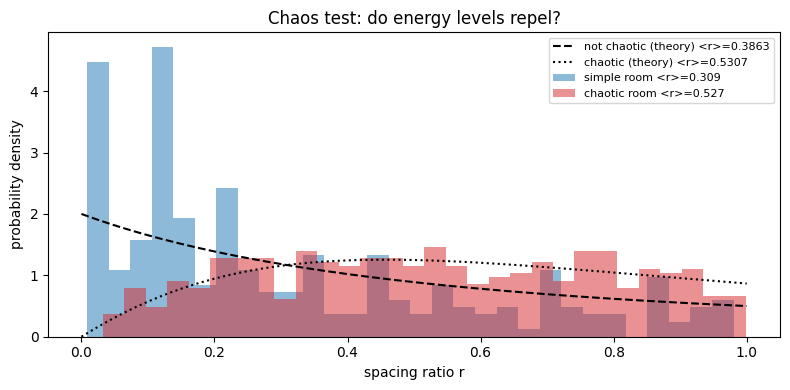

In [ ]:
R_POISSON, R_GOE = 0.3863, 0.5307


def level_spacing_ratios(p: RoomParams, frac=0.5, tol=1e-8):
    E = np.linalg.eigvalsh(hamiltonian(p).to_matrix())
    cut = int(len(E) * (1 - frac) / 2)               # keep middle of spectrum
    s = np.diff(E[cut: len(E) - cut])
    s = s[s > tol]                                   # drop exact degeneracies
    r = np.minimum(s[1:], s[:-1]) / np.maximum(s[1:], s[:-1])
    return r.mean(), r


rr = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rr, 2 / (1 + rr) ** 2, "k--", label=f"not chaotic (theory) <r>={R_POISSON}")
ax.plot(rr, 2 * 27 / 8 * (rr + rr**2) / (1 + rr + rr**2) ** 2.5, "k:",
        label=f"chaotic (theory) <r>={R_GOE}")
r_means = {}
for name, p in ROOMS.items():
    r_means[name], r = level_spacing_ratios(replace(p, n_room=9))
    ax.hist(r, bins=30, density=True, alpha=0.5, color=COLORS[name],
            label=f"{name} room <r>={r_means[name]:.3f}")
ax.set(xlabel="spacing ratio r", ylabel="probability density",
       title="Chaos test: do energy levels repel?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Summary and saving the training data

In [ ]:
print(f"{'room':<8} {'min|r| t>5':>11} {'max|r| t>5':>11} {'Trotter err':>12} {'<r>':>7}")
for name, (lo, hi, err) in summary.items():
    print(f"{name:<8} {lo:>11.3f} {hi:>11.3f} {err:>12.3f} {r_means[name]:>7.3f}")

np.savez("trajectories.npz", **data, bell_dirs=np.array(list(BELL_DIRS)))
print("\nSaved trajectories.npz  ->", {k: v.shape for k, v in data.items()})

room      min|r| t>5  max|r| t>5  Trotter err     <r>
simple         0.560       0.929        0.037   0.309
chaotic        0.187       0.362        0.010   0.527

Saved trajectories.npz  -> {'times': (601,), 'simple': (6, 601, 3), 'chaotic': (6, 601, 3)}


---
# Part II — The fake room

## 7. The fake room: a latent quantum neural ODE

**Idea in one line:** throw away the 5-qubit room and replace it with **$k$ helper qubits** whose interactions we *learn*,
so that the bell behaves exactly as it did in the real room.

| | Real room (Part I) | Fake room (Part II) |
|---|---|---|
| Qubits | bell + 5 room qubits | bell + $k$ helpers ($k = 0, 1, 2, 3$) |
| Rule | fixed Ising Hamiltonian $H$ | **trainable** Hamiltonian $H_\theta$ |
| Room/helpers start in | $\lvert{+y}\rangle$ | $\lvert 0\rangle$ |
| What we look at | bell's arrow only | bell's arrow only |

### Why this is a *neural ODE*
A classical neural ODE **[5]** describes a system by a learned rule for how it changes moment to moment:
$\dfrac{d\mathbf{x}}{dt} = f_\theta(\mathbf{x})$, where $f_\theta$ is a neural network. Our rule is the Schrödinger equation with a learned Hamiltonian:

$$\frac{d}{dt}\lvert\Psi(t)\rangle = -i\,H_\theta\,\lvert\Psi(t)\rangle,
\qquad H_\theta = \sum_j \theta_j P_j,
\qquad r_a(t) = \langle\Psi(t)\rvert\,\sigma_a^{(\text{bell})}\,\lvert\Psi(t)\rangle .$$

The building blocks $P_j$ are **all** single-qubit Paulis ($X, Y, Z$) on every qubit, plus **all nine** two-qubit Paulis
($XX, XY, \dots, ZZ$) between neighbours in the chain *bell – helper 1 – helper 2 – …*. The knobs $\theta_j$ are the trainable parameters.

### Why *latent* (hidden) qubits
The helpers are never measured; they are **hidden memory**. This mirrors two classical ideas:
augmented neural ODEs **[6]** (extra hidden dimensions let a model represent dynamics the visible variables alone cannot)
and latent ODEs **[7]** (the dynamics live in a hidden space and are projected down to what we observe).
The physics version of the same idea is the **pseudomode** picture of open quantum systems **[8, 9]**, where a complicated
environment is replaced by a few effective modes.

### Why we need at least one helper
With $k=0$ the bell evolves alone, so its arrow just rotates and its **length stays exactly 1 forever**: it can never leak
information. Leaking requires somewhere to leak *to*. And the echoes of the simple room are information flowing *back*
from that somewhere: this backflow is the textbook signature of **non-Markovian** (memory-ful) dynamics **[10]**.

### Model size
$k$ helpers give $3(k+1) + 9k = 12k + 3$ parameters:

| helpers $k$ | 0 | 1 | 2 | 3 |
|---|---|---|---|---|
| parameters | 3 | 15 | 27 | 39 |
| hidden space size $2^{k+1}$ | 2 | 4 | 8 | 16 |

### How this differs from related work
| Approach | What is learned | Memory |
|---|---|---|
| Hamiltonian learning **[16]** | the Hamiltonian of the *observed* system | none (system assumed closed) |
| Lindblad / Markovian fits | decay rates of the observed system | none (memoryless) |
| Quantum reservoir computing **[17]** | only a classical readout; the quantum reservoir is fixed | fixed, untrained |
| **This project** | Hamiltonian of system **+ hidden helpers** | **trained quantum memory** |

In [ ]:
import itertools
from scipy.optimize import minimize


def ansatz_terms(k):
    # Pauli building blocks P_j for bell (qubit 0) + k helpers in a chain.
    n = 1 + k
    terms = [(P, [q]) for q in range(n) for P in "XYZ"]                     # 1-qubit
    terms += [(P + Q, [q, q + 1]) for q in range(n - 1)                     # 2-qubit
              for P, Q in itertools.product("XYZ", repeat=2)]
    return terms


class FakeRoom:
    # Bell + k hidden helper qubits evolving under H_theta = sum_j theta_j P_j.

    def __init__(self, k):
        self.k, self.n = k, 1 + k
        self.terms = ansatz_terms(k)
        mat = lambda lbl, q: SparsePauliOp.from_sparse_list([(lbl, q, 1.0)], self.n).to_matrix()
        self.P = np.stack([mat(l, q) for l, q in self.terms])               # (J, dim, dim)
        self.O = np.stack([mat(a, [0]) for a in "XYZ"])                     # bell X, Y, Z
        self.psi0 = np.stack([Statevector(self.prep(d)).data for d in BELL_DIRS])  # (6, dim)

    @property
    def n_params(self):
        return len(self.terms)

    def prep(self, bell_dir):
        # Bell along bell_dir (same gates as the real room); helpers stay in |0>.
        qc = QuantumCircuit(self.n)
        theta, phi = BELL_DIRS[bell_dir]
        qc.ry(theta, 0)
        qc.rz(phi, 0)
        return qc

    def hamiltonian(self, theta):
        return SparsePauliOp.from_sparse_list(
            [(l, q, float(v)) for (l, q), v in zip(self.terms, theta)], self.n)

    def _evolve(self, theta, times):
        E, V = np.linalg.eigh(np.tensordot(theta, self.P, 1))
        c = self.psi0 @ V.conj()                       # V^dagger psi0, shape (6, dim)
        ph = np.exp(-1j * np.outer(times, E))          # e^{-iEt}, shape (T, dim)
        psi = np.einsum("ij,tj,dj->dti", V, ph, c)     # |Psi_d(t)>, shape (6, T, dim)
        r = np.real(np.einsum("dti,aij,dtj->dta", psi.conj(), self.O, psi))
        return E, V, c, ph, psi, r

    def predict(self, theta, times):
        # Bell arrow for all 6 start directions: shape (6, T, 3).
        return self._evolve(theta, times)[-1]

    def loss_and_grad(self, theta, times, target):
        # Mean squared error and its exact gradient (Daleckii-Krein formula).
        E, V, c, ph, psi, r = self._evolve(theta, times)
        err = r - target
        loss = np.mean(err ** 2)
        w = np.einsum("dta,aij,dtj->dti", err, self.O, psi)     # sum_a err_a O_a |Psi>
        w_eig = np.einsum("ji,dtj->dti", V.conj(), w)           # in eigenbasis of H
        dE = E[:, None] - E[None, :]
        deg = np.abs(dE) < 1e-9
        fm, fn = ph[:, :, None], ph[:, None, :]
        Phi = np.where(deg[None], -1j * times[:, None, None] * fm,
                       (fm - fn) / np.where(deg, 1.0, dE)[None])  # divided differences
        M = np.einsum("dtm,tmn,dn->mn", w_eig.conj(), Phi, c)
        P_eig = np.einsum("am,jab,bn->jmn", V.conj(), self.P, V)
        grad = (4 / err.size) * np.real(np.einsum("jmn,mn->j", P_eig, M))
        return loss, grad


for k in range(4):
    print(f"k = {k}: {FakeRoom(k).n_params} parameters")

k = 0: 3 parameters
k = 1: 15 parameters
k = 2: 27 parameters
k = 3: 39 parameters


### How the fake room learns: the loss and its gradient

**Loss** = mean squared error between predicted and true bell arrows, over all 6 start directions, all training times and
all 3 arrow components:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{d,\,t,\,a}\big(r_a^{\theta}(d,t) - r_a^{\text{true}}(d,t)\big)^2 .$$

**Gradient.** To improve the knobs we need $\partial\mathcal{L}/\partial\theta_j$, which means differentiating $e^{-iH_\theta t}$.
Write $H_\theta = V\,\mathrm{diag}(E)\,V^\dagger$. The derivative of a matrix function in its eigenbasis is the
**Daleckii–Krein formula** **[11]**:

$$\frac{\partial e^{-iH_\theta t}}{\partial \theta_j} = V\Big[(V^\dagger P_j V)\circ \Phi(t)\Big]V^\dagger,
\qquad
\Phi_{mn}(t) = \begin{cases}\dfrac{e^{-iE_m t}-e^{-iE_n t}}{E_m - E_n} & E_m \ne E_n\\[2mm] -it\,e^{-iE_m t} & E_m = E_n\end{cases}$$

($\circ$ = element-wise product.) This gives the **exact** gradient of all parameters from one diagonalisation, which is
cheap because the fake room is tiny. On real hardware the same gradient would be measured with the **parameter-shift rule**
**[12]**; here we train in simulation and only *run* the trained model on hardware later (Part 8).

In [ ]:
rng = np.random.default_rng(0)
model = FakeRoom(2)
theta = rng.normal(size=model.n_params)
t_chk = np.linspace(0, 5, 11)
target = rng.uniform(-0.5, 0.5, size=(6, len(t_chk), 3))

_, g_exact = model.loss_and_grad(theta, t_chk, target)
eps = 1e-6
g_fd = np.array([(model.loss_and_grad(theta + eps * e, t_chk, target)[0]
                  - model.loss_and_grad(theta - eps * e, t_chk, target)[0]) / (2 * eps)
                 for e in np.eye(model.n_params)])
print(f"max relative difference, exact vs finite differences: "
      f"{np.abs(g_exact - g_fd).max() / np.abs(g_fd).max():.1e}")

max relative difference, exact vs finite differences: 3.8e-09


A relative difference around $10^{-8}$ (finite-difference noise level) confirms the gradient is correct.

### The fake room is a real quantum circuit
So far the fake room is simulated with matrices. To run it on a quantum computer, $e^{-iH_\theta t}$ must become gates.
Qiskit's `PauliEvolutionGate` does this with the same Suzuki–Trotter formula **[2]** used for the real room; we then compile
to IBM's native gate set (`rz`, `sx`, `x`, `cx`) and check that the circuit gives the same bell arrow as the matrix model.

In [ ]:
import warnings
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter

warnings.filterwarnings("ignore", category=UserWarning)


def fake_room_circuit(model, theta, bell_dir, t, steps):
    qc = model.prep(bell_dir)
    gate = PauliEvolutionGate(model.hamiltonian(theta), time=t,
                              synthesis=SuzukiTrotter(order=2, reps=steps))
    qc.append(gate, range(model.n))
    return transpile(qc, basis_gates=["rz", "sx", "x", "cx"], optimization_level=1)


obs = bell_observables(model.n)
t_test = 2.0
exact = model.predict(theta, np.array([t_test]))[list(BELL_DIRS).index("+x"), 0]
print(f"{'Trotter steps':>13} {'CNOTs':>6} {'max error vs matrix model':>27}")
for steps in (10, 40):
    qc = fake_room_circuit(model, theta, "+x", t_test, steps)
    ev = StatevectorEstimator().run([(qc, obs)]).result()[0].data.evs
    print(f"{steps:>13} {qc.count_ops()['cx']:>6} {np.abs(ev - exact).max():>27.4f}")

Trotter steps  CNOTs   max error vs matrix model


           10    700                      0.1300


           40   2800                      0.0072


The circuit reproduces the matrix model, and the error drops about $16\times$ when the step count goes up $4\times$, the
expected $dt^2$ scaling of 2nd-order Trotter.

**Note for Part 8 (hardware).** Thousands of CNOTs are far too many for today's noisy hardware. Because the fake room is
tiny, there is a much better option: for $k=1$ the whole evolution $e^{-iH_\theta t}$ is a two-qubit gate, and **any**
two-qubit gate can be compiled exactly with at most **3 CNOTs**, for any time $t$ **[18]**. That is a big practical
advantage of a small learned model over simulating the full real room.

## 8. Training the fake room

**Train/test split (forecasting):**
- **Train** on $0 \le t \le 10$ (41 time points, every 0.25)
- **Test** on $10 < t \le 20$: the fake room must **predict the future** it never saw

**Optimiser.** L-BFGS-B **[13]** from SciPy **[15]**, a quasi-Newton method that works very well for smooth problems with
few parameters. The loss landscape is non-convex (many valleys), so we start from **several random initial knob settings**
and keep the best (*random restarts*). Seeds are fixed so every run gives the same result.

We train $k = 0, 1, 2$ on both rooms here; $k = 3$ and the full scaling study follow in Section 9.

In [ ]:
TRAIN = slice(0, 201, 5)      # t = 0, 0.25, ..., 10   (indices into t_fine, step 0.05)
TEST = slice(205, 401, 5)     # t = 10.25, ..., 20
t_train, t_test = t_fine[TRAIN], t_fine[TEST]


def train_fake_room(k, target, restarts=6, seed=0):
    # Fit a k-helper fake room to target (6, T, 3) on t_train.
    # Returns (model, best theta, best loss, losses of all restarts).
    model = FakeRoom(k)
    rng = np.random.default_rng(seed)
    best, losses = None, []
    for _ in range(restarts):
        theta0 = rng.normal(0, 0.5, model.n_params)
        res = minimize(model.loss_and_grad, theta0, args=(t_train, target),
                       jac=True, method="L-BFGS-B", options={"maxiter": 3000})
        losses.append(res.fun)
        if best is None or res.fun < best.fun:
            best = res
    return model, best.x, best.fun, np.array(losses)


fits = {}
print(f"{'room':<8} {'k':>2} {'params':>7} {'train MSE':>10} {'test MSE':>9}")
for name in ROOMS:
    for k in (0, 1, 2):
        model, theta, train_mse, losses = train_fake_room(k, data[name][:, TRAIN])
        test_mse = np.mean((model.predict(theta, t_test) - data[name][:, TEST]) ** 2)
        fits[name, k] = (model, theta, train_mse, test_mse, losses)
        print(f"{name:<8} {k:>2} {model.n_params:>7} {train_mse:>10.4f} {test_mse:>9.4f}")

room      k  params  train MSE  test MSE
simple    0       3     0.1908    0.1953


simple    1      15     0.0986    0.1138


simple    2      27     0.0130    0.0329
chaotic   0       3     0.1721    0.2337


chaotic   1      15     0.0519    0.1986


chaotic   2      27     0.0145    0.1061


### What the fits look like
Solid line = real room, dashed = fake room. The grey band is the **test window** (never seen in training).

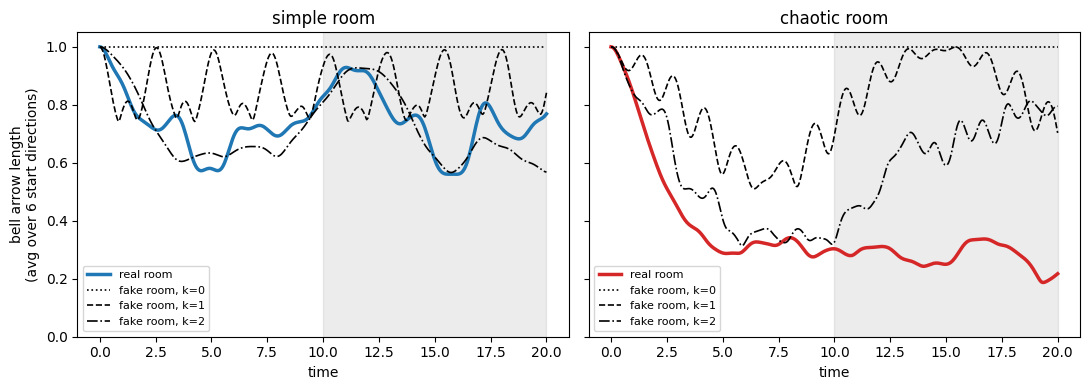

In [ ]:
t_plot = t_fine[t_fine <= 20]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ROOMS):
    true_len = np.linalg.norm(data[name][:, : len(t_plot)], axis=2).mean(axis=0)
    ax.plot(t_plot, true_len, color=COLORS[name], lw=2.5, label="real room")
    for k, ls in zip((0, 1, 2), (":", "--", "-.")):
        model, theta, *_ = fits[name, k]
        pred_len = np.linalg.norm(model.predict(theta, t_plot), axis=2).mean(axis=0)
        ax.plot(t_plot, pred_len, "k", ls=ls, lw=1.2, label=f"fake room, k={k}")
    ax.axvspan(10, 20, color="grey", alpha=0.15)
    ax.set(title=f"{name} room", xlabel="time", ylim=(0, 1.05))
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("bell arrow length\n(avg over 6 start directions)")
plt.tight_layout()
plt.show()

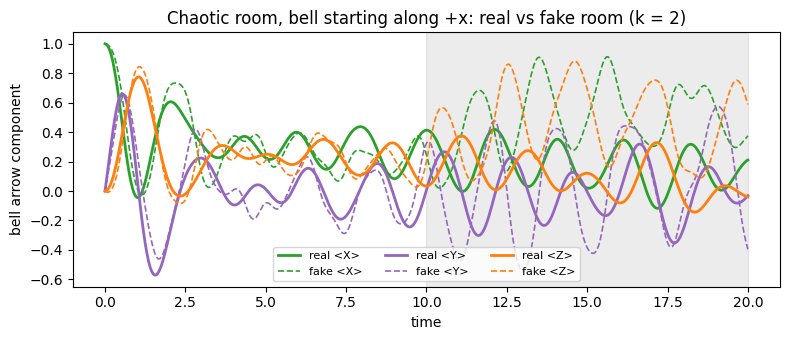

In [ ]:
# Zoom in on one start direction: the three arrow components for the chaotic room, k = 2
model, theta, *_ = fits["chaotic", 2]
i = list(BELL_DIRS).index("+x")
pred = model.predict(theta, t_plot)[i]
fig, ax = plt.subplots(figsize=(8, 3.5))
for a, (lbl, col) in enumerate(zip("XYZ", ("tab:green", "tab:purple", "tab:orange"))):
    ax.plot(t_plot, data["chaotic"][i, : len(t_plot), a], color=col, lw=2, label=f"real <{lbl}>")
    ax.plot(t_plot, pred[:, a], color=col, ls="--", lw=1.2, label=f"fake <{lbl}>")
ax.axvspan(10, 20, color="grey", alpha=0.15)
ax.set(xlabel="time", ylabel="bell arrow component",
       title="Chaotic room, bell starting along +x: real vs fake room (k = 2)")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

### What we learn so far
- **$k=0$ fails completely**, as predicted: the dotted line stays at length 1 because a lone bell cannot leak. Memory is necessary.
- **Each extra helper helps a lot.** Going from 1 to 2 helpers cuts the training error about $8\times$ (simple room) and
  $4\times$ (chaotic room).
- **The chaotic room is much harder to forecast.** With 2 helpers the *training* errors of the two rooms are almost equal
  (≈0.013 vs ≈0.015), but on the unseen test window the chaotic room's error is about **3× larger**. In the plot, the
  $k=2$ fake room follows the simple room's echoes into the future reasonably well, but for the chaotic room it produces a
  **false echo** right after $t = 10$: the arrow grows back although the real one stays low.
- **Why the false echo happens.** A unitary fake room with $k$ helpers has only $2^{k+1}$ energy levels, so the bell's
  signal is a sum of a few oscillations, and any such sum eventually comes back. A chaotic environment instead behaves
  like a system with very many levels whose oscillations never line up again. To imitate it for longer, the fake room
  needs more levels, i.e. **more helpers**. How fast the needed $k$ grows is exactly what the scaling sweep in Section 9 measures.

## 9. Scaling sweep: how much memory does each room need?

Section 8 hinted that the chaotic room needs more memory. Now we measure it properly by adding a **third helper** and asking
two questions for $k = 1, 2, 3$:

1. **Accuracy:** how small do the training and test errors get?
2. **Forecast horizon:** how long does the fake room stay accurate before it drifts away (e.g. into a false echo)?

**Where is the finish line?** The real room has $1 + 5 = 6$ qubits, i.e. $2^6 = 64$ energy levels. With $k = 5$ helpers our
fake room could reproduce it *exactly*: the real Hamiltonian is also a chain of 1- and 2-qubit Pauli terms, so it lies inside
our family of $H_\theta$. The only difference is that the real room starts in $\lvert{+y}\rangle$ and the helpers in
$\lvert 0\rangle$, which is undone by a local change of basis that keeps $H_\theta$ inside the same family. So the real question
is: **how far below $k = 5$ can we go, and does chaos push that number up?**

| helpers $k$ | 1 | 2 | 3 | 5 (exact) |
|---|---|---|---|---|
| energy levels $2^{k+1}$ | 4 | 8 | 16 | 64 |

In [ ]:
for name in ROOMS:                                   # add k = 3 to the fits from Section 8
    model, theta, train_mse, losses = train_fake_room(3, data[name][:, TRAIN])
    test_mse = np.mean((model.predict(theta, t_test) - data[name][:, TEST]) ** 2)
    fits[name, 3] = (model, theta, train_mse, test_mse, losses)

K_SWEEP = (1, 2, 3)
print(f"{'room':<8} {'k':>2} {'params':>7} {'levels':>7} {'train MSE':>10} "
      f"{'test MSE':>9} {'restart spread (train)':>24}")
for name in ROOMS:
    for k in K_SWEEP:
        model, theta, tr, te, losses = fits[name, k]
        print(f"{name:<8} {k:>2} {model.n_params:>7} {2 ** model.n:>7} {tr:>10.4f} {te:>9.4f}"
              f"   {losses.min():.4f} - {np.median(losses):.4f} (best - median)")

room      k  params  levels  train MSE  test MSE   restart spread (train)
simple    1      15       4     0.0986    0.1138   0.0986 - 0.1445 (best - median)
simple    2      27       8     0.0130    0.0329   0.0130 - 0.0315 (best - median)
simple    3      39      16     0.0025    0.0204   0.0025 - 0.0077 (best - median)
chaotic   1      15       4     0.0519    0.1986   0.0519 - 0.0950 (best - median)
chaotic   2      27       8     0.0145    0.1061   0.0145 - 0.0207 (best - median)
chaotic   3      39      16     0.0030    0.0463   0.0030 - 0.0060 (best - median)


### Measuring the forecast horizon

At each time we compute the RMS error of the fake room, over all 6 start directions and 3 arrow components:

$$e(t) = \sqrt{\frac{1}{18}\sum_{d,a}\big(r_a^{\theta}(d,t) - r_a^{\text{true}}(d,t)\big)^2}.$$

$e(t)$ wiggles a lot, so we smooth it with a running average over 1 time unit, giving $\bar e(t)$. Then, following the
*valid prediction time* used for chaotic forecasting in machine learning **[19]**:

- **Valid time** $T_{\text{valid}}$ = the first time $\bar e(t)$ exceeds a tolerance $\varepsilon$ (we use $\varepsilon = 0.15$).
- **Forecast horizon** = $T_{\text{valid}} - 10$: how far *beyond the training window* the prediction stays good.
  If $T_{\text{valid}} < 10$, the model already fails inside its own training data.

Because any tolerance is a choice, we also report $\varepsilon = 0.10$ and $0.20$ to show the conclusions don't depend on it.

In [ ]:
EPS, EPS_LIST, T_TRAIN_END = 0.15, (0.10, 0.15, 0.20), 10.0
SMOOTH = int(round(1.0 / DT_FINE))                    # 1 time unit = 20 grid points


def rms_error_curve(name, k):
    model, theta, *_ = fits[name, k]
    err = model.predict(theta, t_fine) - data[name]
    e = np.sqrt(np.mean(err ** 2, axis=(0, 2)))
    box = np.ones(SMOOTH)
    # running mean; dividing by the window count keeps the ends (t = 0, t = 30) unbiased
    e_smooth = np.convolve(e, box, mode="same") / np.convolve(np.ones_like(e), box, mode="same")
    return e, e_smooth


def valid_time(e_smooth, eps):
    above = e_smooth > eps
    return t_fine[np.argmax(above)] if above.any() else t_fine[-1]


curves = {(name, k): rms_error_curve(name, k) for name in ROOMS for k in K_SWEEP}

print(f"{'room':<8} {'k':>2} " + " ".join(f"{'T_valid(eps=' + str(e) + ')':>18}" for e in EPS_LIST)
      + f" {'horizon (eps=0.15)':>20}")
horizon, t_valid = {}, {}
for name in ROOMS:
    for k in K_SWEEP:
        tv = [valid_time(curves[name, k][1], e) for e in EPS_LIST]
        h = tv[1] - T_TRAIN_END
        horizon[name, k], t_valid[name, k] = h, tv[1]
        h_txt = f"{h:+.2f}" if h > 0 else "fails in training"
        print(f"{name:<8} {k:>2} " + " ".join(f"{v:>18.2f}" for v in tv) + f" {h_txt:>20}")

room      k   T_valid(eps=0.1)  T_valid(eps=0.15)   T_valid(eps=0.2)   horizon (eps=0.15)
simple    1               0.25               0.45               0.65    fails in training
simple    2               1.05               1.90              11.95    fails in training
simple    3              11.00              15.80              17.25                +5.80
chaotic   1               0.80               1.25               1.90    fails in training
chaotic   2               1.25               2.25              10.45    fails in training
chaotic   3              10.35              10.70              11.00                +0.70


### Error over time

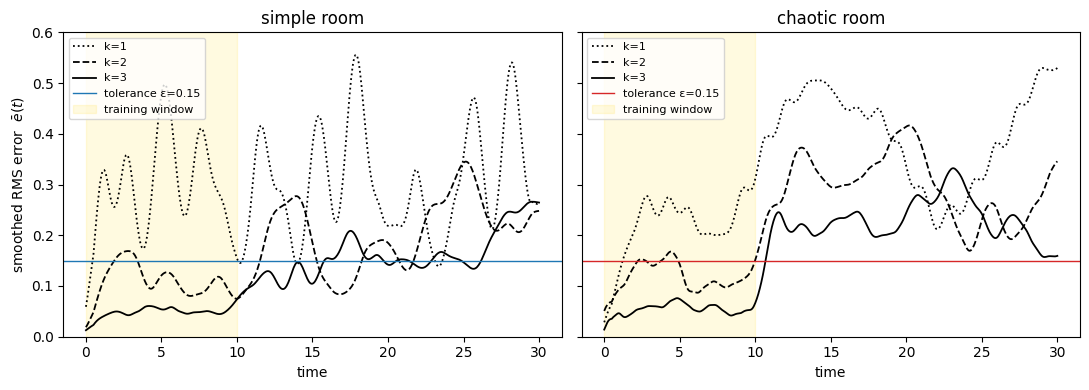

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ROOMS):
    for k, ls in zip(K_SWEEP, (":", "--", "-")):
        ax.plot(t_fine, curves[name, k][1], "k", ls=ls, lw=1.3, label=f"k={k}")
    ax.axhline(EPS, color=COLORS[name], lw=1, label=f"tolerance ε={EPS}")
    ax.axvspan(0, T_TRAIN_END, color="gold", alpha=0.12, label="training window")
    ax.set(title=f"{name} room", xlabel="time", ylim=(0, 0.6))
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("smoothed RMS error  $\\bar e(t)$")
plt.tight_layout()
plt.show()

### Summary plots: accuracy and horizon vs memory

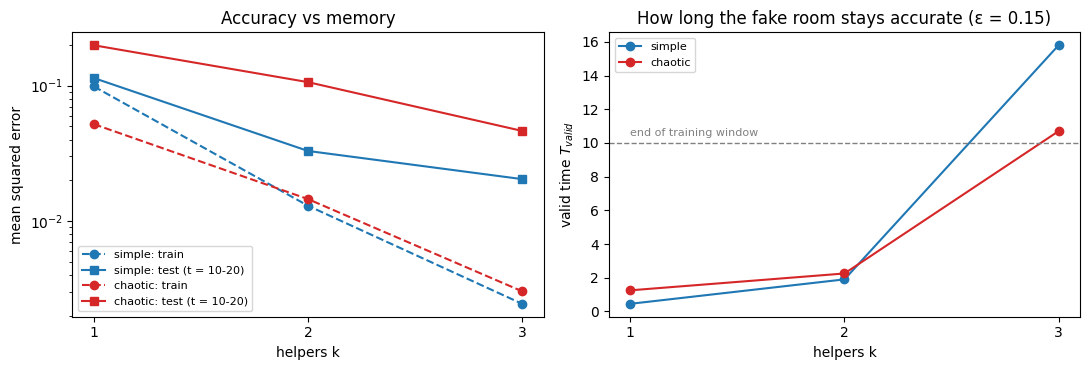

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for name in ROOMS:
    tr = [fits[name, k][2] for k in K_SWEEP]
    te = [fits[name, k][3] for k in K_SWEEP]
    ax1.semilogy(K_SWEEP, tr, "o--", color=COLORS[name], label=f"{name}: train")
    ax1.semilogy(K_SWEEP, te, "s-", color=COLORS[name], label=f"{name}: test (t = 10-20)")
    ax2.plot(K_SWEEP, [t_valid[name, k] for k in K_SWEEP], "o-",
             color=COLORS[name], label=name)
ax1.set(xlabel="helpers k", ylabel="mean squared error", xticks=K_SWEEP,
        title="Accuracy vs memory")
ax2.axhline(T_TRAIN_END, color="grey", ls="--", lw=1)
ax2.text(K_SWEEP[0], T_TRAIN_END + 0.4, "end of training window", fontsize=8, color="grey")
ax2.set(xlabel="helpers k", ylabel="valid time $T_{valid}$", xticks=K_SWEEP,
        title=f"How long the fake room stays accurate (ε = {EPS})")
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

### The best fake rooms ($k = 3$) out to $t = 30$

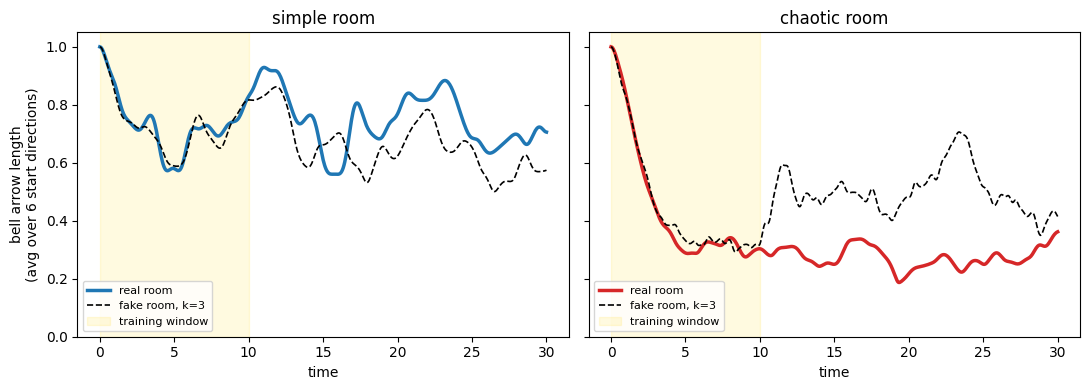

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ROOMS):
    model, theta, *_ = fits[name, 3]
    ax.plot(t_fine, np.linalg.norm(data[name], axis=2).mean(axis=0),
            color=COLORS[name], lw=2.5, label="real room")
    ax.plot(t_fine, np.linalg.norm(model.predict(theta, t_fine), axis=2).mean(axis=0),
            "k--", lw=1.2, label="fake room, k=3")
    ax.axvspan(0, T_TRAIN_END, color="gold", alpha=0.12, label="training window")
    ax.set(title=f"{name} room", xlabel="time", ylim=(0, 1.05))
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("bell arrow length\n(avg over 6 start directions)")
plt.tight_layout()
plt.show()

### Findings
| | simple room | chaotic room |
|---|---|---|
| Train MSE, $k=1 \to 3$ | 0.099 → 0.0025 | 0.052 → 0.0030 |
| Test MSE ($t = 10$–$20$), $k=1 \to 3$ | 0.114 → 0.020 | 0.199 → 0.046 |
| Test / train error at $k=3$ | ≈ 8× | ≈ 15× |
| Valid time $T_{\text{valid}}$ at $k=3$ ($\varepsilon = 0.15$) | **15.8** | **10.7** |
| Forecast horizon beyond training at $k=3$ | **+5.8** | **+0.7** |

1. **Memory is the bottleneck.** With 1 or 2 helpers the fake room cannot even stay within tolerance *inside* its own
   training window (valid time below 2.3 in both rooms). With 3 helpers (16 levels) it fits the training window well in
   both rooms, with nearly identical training errors (0.0025 vs 0.0030).
2. **Same memory, very different forecasts.** At $k = 3$ the fake room predicts the simple room about **5.8 time units**
   past the end of its training data, but the chaotic room only about **0.7**, roughly **8× less**. The ordering holds for
   every tolerance we tried ($\varepsilon = 0.10, 0.15, 0.20$).
3. **The failure mode is the false echo.** In the last plot, the $k=3$ fake room tracks the chaotic room perfectly until
   $t = 10$ and then its arrow climbs back up to 0.5–0.7 while the real one stays near 0.3. The error-over-time plot shows
   the same thing as a sudden jump right after the training window.
4. **Fitting the past is not understanding the future.** With 1 helper the chaotic room is actually *easier* to fit
   (training error 0.052 vs 0.099), because a fast decay to a plateau is a simpler shape than repeated echoes. But that fit
   does not forecast at all. The generalisation gap (test ÷ train) is about twice as large for the chaotic room at $k = 3$.

**Physical interpretation.** The simple room is integrable: its bell signal is built from a few clean, regularly spaced
frequencies, which a 16-level memory can capture and continue. In the chaotic room the levels repel and are irregularly
spaced (Section 5), so the bell's signal mixes many unrelated frequencies. A small memory can mimic that mixture over a
finite window, but its own few frequencies soon line up again and produce a revival the real room never shows.

**Pitch line:** *with the same 16-level quantum memory, a learned model forecasts an integrable environment about 8× further
beyond its training data than a chaotic one.*

**Caveats**
- One training window ($0 \le t \le 10$), one set of random restarts (seed 0) and one room size (5 qubits).
- The real chaotic room is itself finite (64 levels), so at very long times it also fluctuates.
- $k = 4$ and $k = 5$ (where an exact solution exists) are the natural next points, but cost much more training time;
  whether the optimiser actually *finds* the exact solution at $k = 5$ is itself an open question.
- The valid time depends on the tolerance $\varepsilon$; we report three values for this reason.

---
# Part III — Is quantum memory actually better?

## 10. Classical comparison (and a better quantum model)

Any claim about a quantum model is only meaningful against good classical models doing **the same job under the same
rules**. The rules we enforce for every model:

| Rule | Why |
|---|---|
| Same data, same train window ($0 \le t \le 10$) and test window | identical task |
| Same loss (mean squared error on the bell arrow) | identical objective |
| Same optimiser: L-BFGS-B **[13]**, 6 random restarts, seed 0 | identical training effort |
| Roughly matched parameter counts (≈15, ≈27, ≈39) | identical model budget |
| Every model starts *exactly* at the true starting arrow $\vec r_0$ | no model gets the $t=0$ point for free |

### The contenders

**(a) Classical linear state-space model.** The standard tool of system identification in control engineering **[20]**.
A hidden state $\mathbf z = (\vec r,\ \mathbf h)$ of dimension $d$ follows

$$\frac{d\mathbf z}{dt} = A\,\mathbf z + \mathbf b,\qquad \mathbf h(0) = W\,[\vec r_0;\,1],\qquad \text{output} = \text{first 3 entries of } \mathbf z .$$

$A$ is unconstrained, so the model can oscillate **and decay**. Parameters: $d^2 + d + 4(d-3)$, i.e. 12, 24, 38 for $d = 3, 4, 5$.

**(b) Classical augmented neural ODE [6].** The nonlinear, deep-learning baseline:
$\dfrac{d\mathbf z}{dt} = W_2 \tanh(W_1\mathbf z + \mathbf b_1) + \mathbf b_2$ with $\mathbf z(0) = (\vec r_0, 0, 0)$ (two extra hidden
dimensions), solved with 4th-order Runge–Kutta. Hidden width 1, 2, 3 gives 16, 27, 38 parameters.

**(c) Quantum fake room, unitary.** The model from Sections 7–9 (15, 27, 39 parameters).

**(d) Quantum fake room with leaky helpers (new).** Section 9 showed the unitary fake room fails on chaos because it can
never *forget*: every bit of information eventually comes back as a false echo. Real physics has a fix. In the
**damped-pseudomode** picture of open quantum systems **[9]**, a complicated environment is replaced by a few modes that
themselves slowly leak into a memoryless sink. We give each helper a trainable leak rate $\gamma_q \ge 0$ towards
$\lvert 0\rangle$ (amplitude damping), using the standard Lindblad equation **[21, 22]**:

$$\frac{d\rho}{dt} = -i[H_\theta,\rho] + \sum_{q\in\text{helpers}} \gamma_q\Big(\sigma^-_q\rho\,\sigma^+_q - \tfrac12\{\sigma^+_q\sigma^-_q,\rho\}\Big).$$

The bell itself never leaks directly: all forgetting must pass through the learned quantum memory. This adds only $k$
parameters (16 and 29 for $k = 1, 2$). With all $\gamma_q = 0$ it is exactly model (c), which we check numerically.
$k=3$ is skipped here because its $256\times256$ superoperator makes training slow.

**Implementation.** Models (a), (b), (d) are written in JAX **[23]**, which differentiates through the ODE solver and the
matrix exponential automatically. The optimiser is the same SciPy L-BFGS-B as before.

In [ ]:
import time
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)   # double precision, same as NumPy

# Starting arrows of the 6 directions, (6, 3); must equal the real data at t = 0
R0 = np.array([[np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph), np.cos(th)]
               for th, ph in BELL_DIRS.values()])
assert np.allclose(R0, data["simple"][:, 0])


def unflatten(theta, shapes):
    out, i = [], 0
    for s in shapes:
        n = int(np.prod(s))
        out.append(theta[i:i + n].reshape(s))
        i += n
    return out


class LinearSSM:
    # (a) z = (r, h);  dz/dt = A z + b;  h(0) = W [r0, 1];  output = z[:3]
    family = "classical linear"

    def __init__(self, d):
        self.d, self.label = d, f"d={d}"
        self.shapes = [(d, d), (d,), (d - 3, 4)]
        self.n_params = sum(int(np.prod(s)) for s in self.shapes)

    def traj(self, theta, dt, n):
        A, b, W = unflatten(theta, self.shapes)
        r0 = jnp.asarray(R0)
        z0 = jnp.concatenate([r0, jnp.concatenate([r0, jnp.ones((6, 1))], 1) @ W.T], 1)
        # affine flow as one matrix exponential of the augmented matrix [[A, b], [0, 0]]
        Aa = jnp.zeros((self.d + 1, self.d + 1)).at[: self.d, : self.d].set(A).at[: self.d, self.d].set(b)
        M = jax.scipy.linalg.expm(Aa * dt)
        za = jnp.concatenate([z0, jnp.ones((6, 1))], 1)
        _, rs = jax.lax.scan(lambda z, _: (z @ M.T, z[:, :3]), za, None, length=n)
        return jnp.transpose(rs, (1, 0, 2))


class AugmentedNODE:
    # (b) dz/dt = W2 tanh(W1 z + b1) + b2;  z(0) = (r0, 0, 0);  RK4 with 5 sub-steps per output step
    family = "classical neural ODE"

    def __init__(self, h, d=5, substeps=5):
        self.h, self.d, self.sub, self.label = h, d, substeps, f"width={h}"
        self.shapes = [(h, d), (h,), (d, h), (d,)]
        self.n_params = sum(int(np.prod(s)) for s in self.shapes)

    def traj(self, theta, dt, n):
        W1, b1, W2, b2 = unflatten(theta, self.shapes)
        f = lambda z: jnp.tanh(z @ W1.T + b1) @ W2.T + b2
        z0 = jnp.concatenate([jnp.asarray(R0), jnp.zeros((6, self.d - 3))], 1)
        hh = dt / self.sub

        def rk4(z, _):
            k1 = f(z); k2 = f(z + hh / 2 * k1); k3 = f(z + hh / 2 * k2); k4 = f(z + hh * k3)
            return z + hh / 6 * (k1 + 2 * k2 + 2 * k3 + k4), None

        def step(z, _):
            out = z[:, :3]
            z, _ = jax.lax.scan(rk4, z, None, length=self.sub)
            return z, out

        _, rs = jax.lax.scan(step, z0, None, length=n)
        return jnp.transpose(rs, (1, 0, 2))


class LeakyFakeRoom:
    # (d) bell + k helpers; H_theta as in Section 7; each helper leaks to |0> at rate softplus(g_q)
    family = "quantum (leaky helpers)"

    def __init__(self, k):
        base = FakeRoom(k)
        self.k, self.n, self.label = k, 1 + k, f"k={k}"
        self.D = 2 ** self.n
        self.nH = base.n_params
        self.n_params = base.n_params + k
        self.P = jnp.asarray(base.P)
        lower = lambda q: (SparsePauliOp.from_sparse_list([("X", [q], 0.5)], self.n)
                           + SparsePauliOp.from_sparse_list([("Y", [q], 0.5j)], self.n)).to_matrix()
        self.L = [jnp.asarray(lower(q)) for q in range(1, self.n)]           # sigma^- = |0><1|
        rho0 = np.stack([np.outer(p, p.conj()) for p in base.psi0])
        self.rho0 = jnp.asarray(rho0.reshape(6, -1))                          # row-major vec(rho)
        self.Ovec = jnp.asarray(np.stack([base.O[a].T.reshape(-1) for a in range(3)]))  # Tr(O rho)

    def superoperator(self, theta):
        # vec(A rho B) = (A kron B^T) vec(rho) for row-major vectorisation
        H = jnp.tensordot(theta[: self.nH].astype(complex), self.P, 1)
        I = jnp.eye(self.D)
        S = -1j * (jnp.kron(H, I) - jnp.kron(I, H.T))
        gam = jax.nn.softplus(theta[self.nH:])                                 # rates >= 0
        for q, L in enumerate(self.L):
            LdL = L.conj().T @ L
            S = S + gam[q] * (jnp.kron(L, L.conj()) - 0.5 * jnp.kron(LdL, I) - 0.5 * jnp.kron(I, LdL.T))
        return S

    def traj(self, theta, dt, n):
        M = jax.scipy.linalg.expm(self.superoperator(theta) * dt)
        _, rs = jax.lax.scan(lambda v, _: (v @ M.T, jnp.real(v @ self.Ovec.T)), self.rho0, None, length=n)
        return jnp.transpose(rs, (1, 0, 2))


def train_jax(model, target, dt=0.25, restarts=6, seed=0):
    # Same protocol as train_fake_room: L-BFGS-B, random restarts, keep the best.
    tgt = jnp.asarray(target)
    n = target.shape[1]
    value_and_grad = jax.jit(jax.value_and_grad(lambda th: jnp.mean((model.traj(th, dt, n) - tgt) ** 2)))

    def fun(th):
        v, g = value_and_grad(jnp.asarray(th))
        return float(v), np.asarray(g, dtype=float)

    rng = np.random.default_rng(seed)
    best, losses = None, []
    for _ in range(restarts):
        res = minimize(fun, rng.normal(0, 0.5, model.n_params), jac=True,
                       method="L-BFGS-B", options={"maxiter": 3000})
        losses.append(res.fun)
        if best is None or res.fun < best.fun:
            best = res
    return best.x, best.fun, np.array(losses)


# Check: leaky model with (almost) zero leak = unitary model from Section 7
k_chk, unit_model = 2, FakeRoom(2)
th_chk = np.random.default_rng(1).normal(0, 0.5, unit_model.n_params)
leaky = LeakyFakeRoom(k_chk)
a = np.asarray(leaky.traj(jnp.asarray(np.r_[th_chk, [-50.0] * k_chk]), 0.25, 20))
b = unit_model.predict(th_chk, np.arange(20) * 0.25)
print(f"leaky model with zero leak vs unitary model: max difference {np.abs(a - b).max():.1e}")

leaky model with zero leak vs unitary model: max difference 3.6e-15


### Training all models
All metrics are computed exactly as in Section 9: **test MSE** on $10 < t \le 20$ and **valid time** $T_{\text{valid}}$
($\varepsilon = 0.15$, error smoothed over 1 time unit).

In [ ]:
def forecast_metrics(pred_fine, name):
    # test MSE on (10, 20] and valid time, from a prediction on the fine time grid t_fine
    test_mse = np.mean((pred_fine[:, TEST] - data[name][:, TEST]) ** 2)
    e = np.sqrt(np.mean((pred_fine - data[name]) ** 2, axis=(0, 2)))
    box = np.ones(SMOOTH)
    e_s = np.convolve(e, box, mode="same") / np.convolve(np.ones_like(e), box, mode="same")
    return test_mse, valid_time(e_s, EPS)


results = []          # rows: (family, label, params, room, train, test, T_valid)
preds = {}            # fine-grid predictions for plotting

for name in ROOMS:    # (c) unitary quantum: reuse the fits from Sections 8-9
    for k in (1, 2, 3):
        model, theta, tr, *_ = fits[name, k]
        pred = model.predict(theta, t_fine)
        te, tv = forecast_metrics(pred, name)
        results.append(("quantum (unitary)", f"k={k}", model.n_params, name, tr, te, tv))
        preds["quantum (unitary)", f"k={k}", name] = pred

contenders = ([LinearSSM(d) for d in (3, 4, 5)]
              + [AugmentedNODE(h) for h in (1, 2, 3)]
              + [LeakyFakeRoom(k) for k in (1, 2)])
jax_fits = {}
for model in contenders:
    for name in ROOMS:
        t0 = time.time()
        theta, tr, _ = train_jax(model, data[name][:, TRAIN])
        pred = np.asarray(model.traj(jnp.asarray(theta), DT_FINE, len(t_fine)))
        te, tv = forecast_metrics(pred, name)
        results.append((model.family, model.label, model.n_params, name, tr, te, tv))
        preds[model.family, model.label, name] = pred
        jax_fits[model.family, model.label, name] = (model, theta)
        print(f"trained {model.family:<24} {model.label:<8} on {name:<7} ({time.time() - t0:5.1f} s)")

trained classical linear         d=3      on simple  (  2.2 s)


trained classical linear         d=3      on chaotic (  1.3 s)


trained classical linear         d=4      on simple  (  3.4 s)


trained classical linear         d=4      on chaotic (  2.8 s)


trained classical linear         d=5      on simple  (  5.3 s)


...

trained classical neural ODE     width=3  on chaotic ( 17.4 s)


trained quantum (leaky helpers)  k=1      on simple  (  5.2 s)


trained quantum (leaky helpers)  k=1      on chaotic (  3.0 s)


trained quantum (leaky helpers)  k=2      on simple  ( 45.5 s)


trained quantum (leaky helpers)  k=2      on chaotic ( 15.7 s)


In [ ]:
FAMILIES = ["quantum (unitary)", "quantum (leaky helpers)", "classical linear", "classical neural ODE"]
for name in ROOMS:
    print(f"\n=== {name.upper()} ROOM ===")
    print(f"{'model':<24} {'size':<8} {'params':>6} {'train MSE':>10} {'test MSE':>10} {'T_valid':>8}")
    for fam in FAMILIES:
        for row in results:
            if row[0] == fam and row[3] == name:
                print(f"{fam:<24} {row[1]:<8} {row[2]:>6} {row[4]:>10.4f} {row[5]:>10.4f} {row[6]:>8.2f}")


=== SIMPLE ROOM ===
model                    size     params  train MSE   test MSE  T_valid
quantum (unitary)        k=1          15     0.0986     0.1138     0.45
quantum (unitary)        k=2          27     0.0130     0.0329     1.90
quantum (unitary)        k=3          39     0.0025     0.0204    15.80
quantum (leaky helpers)  k=1          16     0.0260     0.0636     0.95
quantum (leaky helpers)  k=2          29     0.0112     0.0226    10.70
classical linear         d=3          12     0.0412     0.1146     2.30
classical linear         d=4          24     0.0370     0.1037     5.55
classical linear         d=5          38     0.0239    73.4849     2.65
classical neural ODE     width=1      16     0.2614     0.4041     0.00
classical neural ODE     width=2      27     0.0903     0.2962     0.90
classical neural ODE     width=3      38     0.0192     0.7552     5.80

=== CHAOTIC ROOM ===
model                    size     params  train MSE   test MSE  T_valid
quantum (unitary)    

**Stability check.** An unconstrained linear model can learn a growing mode (an eigenvalue of $A$ with positive real
part). Inside the training window this may be invisible, but outside it the prediction explodes. We check the largest
real part of the eigenvalues of the learned $A$:

In [ ]:
for name in ROOMS:
    for d in (3, 4, 5):
        model, theta = jax_fits["classical linear", f"d={d}", name]
        A = unflatten(theta, model.shapes)[0]
        print(f"{name:<8} d={d}: max Re(eigenvalue of A) = {np.linalg.eigvals(A).real.max():+.4f}")

simple   d=3: max Re(eigenvalue of A) = -0.1258
simple   d=4: max Re(eigenvalue of A) = -0.0955
simple   d=5: max Re(eigenvalue of A) = +0.3939
chaotic  d=3: max Re(eigenvalue of A) = -0.1062
chaotic  d=4: max Re(eigenvalue of A) = -0.0684
chaotic  d=5: max Re(eigenvalue of A) = -0.0836


### Accuracy and forecast horizon vs model size

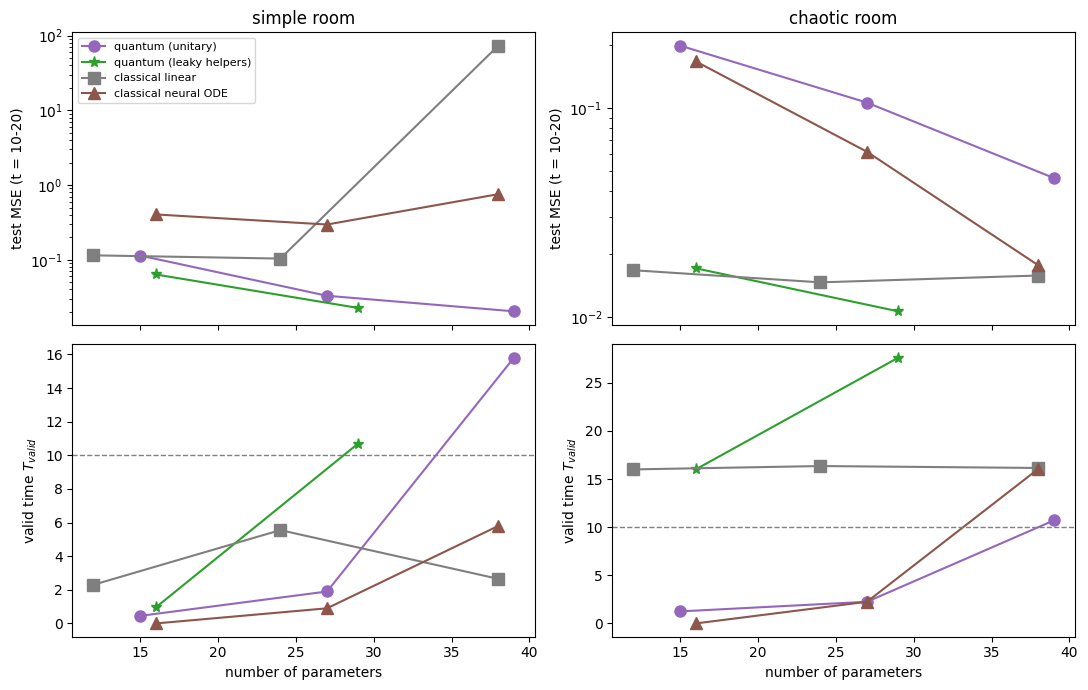

In [ ]:
MARK = {"quantum (unitary)": ("o", "tab:purple"), "quantum (leaky helpers)": ("*", "tab:green"),
        "classical linear": ("s", "tab:gray"), "classical neural ODE": ("^", "tab:brown")}
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for j, name in enumerate(ROOMS):
    for fam in FAMILIES:
        rows = sorted((r for r in results if r[0] == fam and r[3] == name), key=lambda r: r[2])
        p = [r[2] for r in rows]
        mk, col = MARK[fam]
        axes[0, j].semilogy(p, [r[5] for r in rows], marker=mk, color=col, ms=8, label=fam)
        axes[1, j].plot(p, [r[6] for r in rows], marker=mk, color=col, ms=8, label=fam)
    axes[0, j].set(title=f"{name} room", ylabel="test MSE (t = 10-20)")
    axes[1, j].axhline(T_TRAIN_END, color="grey", ls="--", lw=1)
    axes[1, j].set(xlabel="number of parameters", ylabel="valid time $T_{valid}$")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Side by side at a matched budget of ≈ 27 parameters

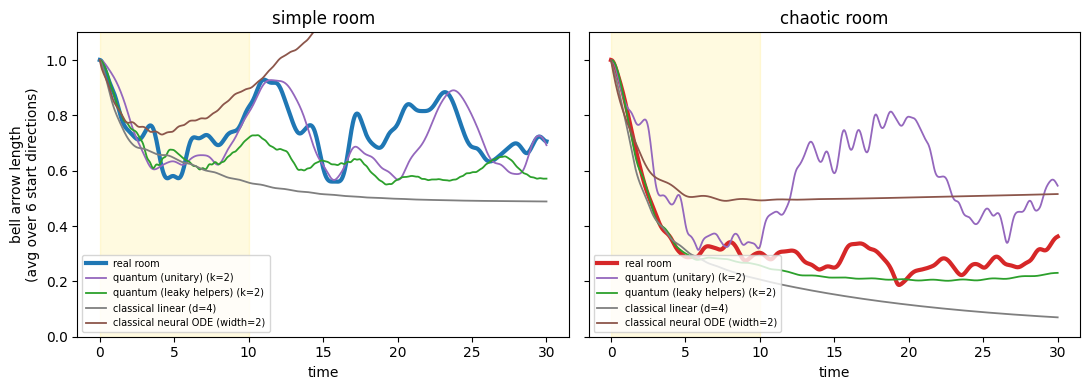

In [ ]:
PICK = [("quantum (unitary)", "k=2"), ("quantum (leaky helpers)", "k=2"),
        ("classical linear", "d=4"), ("classical neural ODE", "width=2")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ROOMS):
    ax.plot(t_fine, np.linalg.norm(data[name], axis=2).mean(axis=0), color=COLORS[name], lw=3, label="real room")
    for fam, lbl in PICK:
        mk, col = MARK[fam]
        ax.plot(t_fine, np.linalg.norm(preds[fam, lbl, name], axis=2).mean(axis=0),
                color=col, lw=1.3, label=f"{fam} ({lbl})")
    ax.axvspan(0, T_TRAIN_END, color="gold", alpha=0.12)
    ax.set(title=f"{name} room", xlabel="time", ylim=(0, 1.1))
    ax.legend(fontsize=7, loc="lower left")
axes[0].set_ylabel("bell arrow length\n(avg over 6 start directions)")
plt.tight_layout()
plt.show()

### Findings

**Results at a matched budget of ≈ 27 parameters**

| Model | Simple room: test MSE / $T_{\text{valid}}$ | Chaotic room: test MSE / $T_{\text{valid}}$ |
|---|---|---|
| Quantum, unitary ($k=2$, 27) | 0.033 / 1.9 | 0.106 / 2.3 |
| Quantum, leaky helpers ($k=2$, 29) | **0.023 / 10.7** | **0.011 / 27.6** |
| Classical linear ($d=4$, 24) | 0.104 / 5.6 | 0.015 / 16.4 |
| Classical neural ODE (width 2, 27) | 0.296 / 0.9 | 0.062 / 2.3 |

1. **Classical models cannot forecast coherent echoes.** In the simple room every classical model has test error ≥ 0.10.
   The best quantum models reach 0.020 (unitary $k=3$) and 0.023 (leaky $k=2$). Extra classical capacity does not fix
   this: the largest neural ODE fits the training window well (0.019) but its forecast error is 0.76, and the largest
   linear model learns an **unstable mode** (eigenvalue real part +0.39), so its forecast explodes (test MSE 73).
2. **Unitary quantum memory cannot forecast chaos.** In the chaotic room, damped classical models beat the unitary
   quantum model at every size. They can *forget*, which a closed quantum system cannot: this is the false echo of
   Section 9.
3. **Leaky quantum memory has the right inductive bias for both rooms.** Adding just $k$ leak rates makes the quantum
   model the best in the chaotic room at every size tested (test MSE 0.011, valid time 27.6 at $k=2$, i.e. 1.7× longer
   than the best classical model) and close to the best in the simple room. Coherent memory reproduces the echoes; the
   leak removes the false ones. This is the damped-pseudomode structure known from open-system physics **[9]**,
   rediscovered here by training.
4. **Honest scope.** These are statements about model structure on small, classically simulable systems, not a
   computational quantum advantage. Every model here, including the quantum ones, was trained on a classical computer.

---
# Part IV — Running on quantum hardware

## 11. The fake room on an IBM quantum computer

**What we run.** The trained **unitary $k=2$ fake rooms** (one per room, 3 qubits). We predict the bell's arrow at times
$t = 0, 1, \dots, 20$ for all 6 start directions. The leaky model needs mid-circuit resets to implement its leak and is
left for future work.

**Exact compilation instead of Trotter steps.** The fake room is so small that $e^{-iH_\theta t}$ can be built as one exact
3-qubit gate (Qiskit's `UnitaryGate`) and compiled straight to hardware gates. The circuit depth then **does not grow with
$t$**: about 29 two-qubit gates for any time, compared with thousands for Trotter steps (Section 7). This is the practical
payoff of a small learned model; the 6-qubit real room would need deep Trotter circuits.

**Two stages.**
1. **Noisy emulation (runs here):** the circuits run on Qiskit Aer with the noise model of **IBM Torino** (a 133-qubit
   Heron device), including gate errors, decoherence and readout errors.
2. **Real hardware (one switch):** the same circuits sent to a real IBM device with `qiskit-ibm-runtime` **[14]**.

**Error mitigation used in the emulation**
- **Qubit selection:** pick the connected chain of 3 qubits with the lowest two-qubit and readout errors.
  (Calibration quality varies a lot across a chip. On IBM Torino qubit 0 has a ~17% readout error, so the default
  layout would be a poor choice.)
- **Readout-error mitigation (REM)** **[24]:** measure the readout qubit prepared in $\lvert0\rangle$ and $\lvert1\rangle$, then
  invert the readout error: $\langle Z\rangle = \big(\langle Z\rangle_{\text{meas}} - (p_{0|1} - p_{1|0})\big) / (1 - p_{0|1} - p_{1|0})$.
- **Zero-noise extrapolation (ZNE)** **[25, 26]:** run each circuit at noise scale 1, 3, 5 by replacing every two-qubit
  gate $G$ with $G\,(G^\dagger G)^{(s-1)/2}$ (*unitary folding*). The ideal circuit is unchanged, but the noise grows about
  $s$ times. Then extrapolate the results back to zero noise.

**On real hardware we additionally switch on** Pauli twirling **[27]**, twirled readout mitigation (TREX) **[28]** and
dynamical decoupling **[29]** through runtime options. These target noise that the emulator does not model well,
namely coherent errors, crosstalk and idling errors.

In [ ]:
from scipy.linalg import expm
from qiskit.circuit.library import UnitaryGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeTorino

fake_backend = FakeTorino()
target = fake_backend.target


def best_chain(target):
    # connected 3-qubit chain (a - m - c) minimising CZ errors + readout error of the measured qubit a
    ro = {q: target["measure"][(q,)].error for q in range(target.num_qubits)}
    cz = target["cz"]
    nbrs = {}
    for a, c in cz.keys():
        nbrs.setdefault(a, set()).add(c)
    best = None
    for a, m in cz.keys():
        for c in nbrs.get(m, ()):
            if c in (a, m):
                continue
            e2 = cz.get((m, c)) or cz.get((c, m))
            score = cz[(a, m)].error + e2.error + 3 * ro[a]
            if best is None or score < best[0]:
                best = (score, [a, m, c])
    return best[1], ro


LAYOUT, readout_err = best_chain(target)
print(f"chosen qubits (bell first): {LAYOUT}")
print(f"readout error of bell qubit: {readout_err[LAYOUT[0]]:.4f}   (qubit 0 would be {readout_err[0]:.4f})")

chosen qubits (bell first): [51, 52, 37]
readout error of bell qubit: 0.0051   (qubit 0 would be 0.1667)


In [ ]:
HW_TIMES = np.arange(0, 20.01, 1.0)
DIRS = list(BELL_DIRS)
SCALES = (1, 3, 5)
SHOTS = 8000
pm = generate_preset_pass_manager(optimization_level=3, backend=fake_backend,
                                  initial_layout=LAYOUT, seed_transpiler=7)


def logical_circuit(model, theta, bell_dir, t, basis=None):
    # Fake-room circuit: prepare bell, apply exact e^{-iH t}, optionally rotate+measure the bell in basis X/Y/Z.
    qc = QuantumCircuit(model.n, 1 if basis else 0)
    qc.compose(model.prep(bell_dir), inplace=True)
    H = np.tensordot(theta, model.P, 1)
    qc.append(UnitaryGate(expm(-1j * H * t)), range(model.n))
    if basis == "X":
        qc.h(0)
    elif basis == "Y":
        qc.sdg(0)
        qc.h(0)
    if basis:
        qc.measure(0, 0)
    return qc


def fold_two_qubit_gates(qc, scale):
    # unitary folding: G -> G (G^dagger G)^((scale-1)/2) for every 2-qubit gate
    out = qc.copy_empty_like()
    for inst in qc.data:
        out.append(inst)
        if inst.operation.num_qubits == 2:
            for _ in range((scale - 1) // 2):
                out.append(inst.operation.inverse(), inst.qubits)
                out.append(inst.operation, inst.qubits)
    return out


model2, theta_demo, *_ = fits["chaotic", 2]
demo = pm.run(logical_circuit(model2, theta_demo, "+x", 7.0, "Z"))
print("compiled fake-room circuit at t = 7:", dict(demo.count_ops()))

compiled fake-room circuit at t = 7: {'sx': 93, 'rz': 85, 'cz': 29, 'x': 1, 'measure': 1}


In [ ]:
noisy_sim = AerSimulator(noise_model=NoiseModel.from_backend(fake_backend), seed_simulator=7)
hw = {}
for name in ROOMS:
    model, theta, *_ = fits[name, 2]
    isa = {(d, t, b): pm.run(logical_circuit(model, theta, d, t, b))
           for d in DIRS for t in HW_TIMES for b in "XYZ"}
    circuits = [fold_two_qubit_gates(isa[d, t, b], s)
                for s in SCALES for d in DIRS for t in HW_TIMES for b in "XYZ"]
    calib = []
    for bit in (0, 1):                                  # readout calibration of the bell qubit
        q = QuantumCircuit(model.n, 1)
        if bit:
            q.x(0)
        q.measure(0, 0)
        calib.append(pm.run(q))
    t0 = time.time()
    res = noisy_sim.run(circuits + calib, shots=SHOTS).result()
    ev = lambda i: (res.get_counts(i).get("0", 0) - res.get_counts(i).get("1", 0)) / SHOTS
    raw = np.array([ev(i) for i in range(len(circuits))]).reshape(len(SCALES), len(DIRS), len(HW_TIMES), 3)
    p10 = res.get_counts(len(circuits)).get("1", 0) / SHOTS        # P(read 1 | prepared 0)
    p01 = res.get_counts(len(circuits) + 1).get("0", 0) / SHOTS    # P(read 0 | prepared 1)
    rem = (raw - (p01 - p10)) / (1 - p01 - p10)
    zne = (15 * rem[0] - 10 * rem[1] + 3 * rem[2]) / 8              # Richardson extrapolation, s = 1, 3, 5
    hw[name] = dict(ideal=model.predict(theta, HW_TIMES), raw=raw[0], rem=rem[0], zne=zne,
                    p10=p10, p01=p01, n_circ=len(circuits))
    print(f"{name}: {len(circuits) + 2} circuits x {SHOTS} shots in {time.time() - t0:.1f} s; "
          f"readout p(1|0)={p10:.4f}, p(0|1)={p01:.4f}")

print(f"\n{'room':<8} {'RMS error vs ideal model':>26}")
print(f"{'':<8} {'raw':>8} {'REM':>8} {'REM+ZNE':>9}")
for name in ROOMS:
    r = hw[name]
    rms = lambda x: np.sqrt(np.mean((x - r['ideal']) ** 2))
    print(f"{name:<8} {rms(r['raw']):>8.4f} {rms(r['rem']):>8.4f} {rms(r['zne']):>9.4f}")
print(f"\nshot-noise floor (1 std of one expectation value): ~{1 / np.sqrt(SHOTS):.3f}")

simple: 1136 circuits x 8000 shots in 19.3 s; readout p(1|0)=0.0050, p(0|1)=0.0047


chaotic: 1136 circuits x 8000 shots in 18.7 s; readout p(1|0)=0.0050, p(0|1)=0.0047

room       RMS error vs ideal model
              raw      REM   REM+ZNE
simple     0.0819   0.0788    0.0469
chaotic    0.0674   0.0647    0.0405

shot-noise floor (1 std of one expectation value): ~0.011


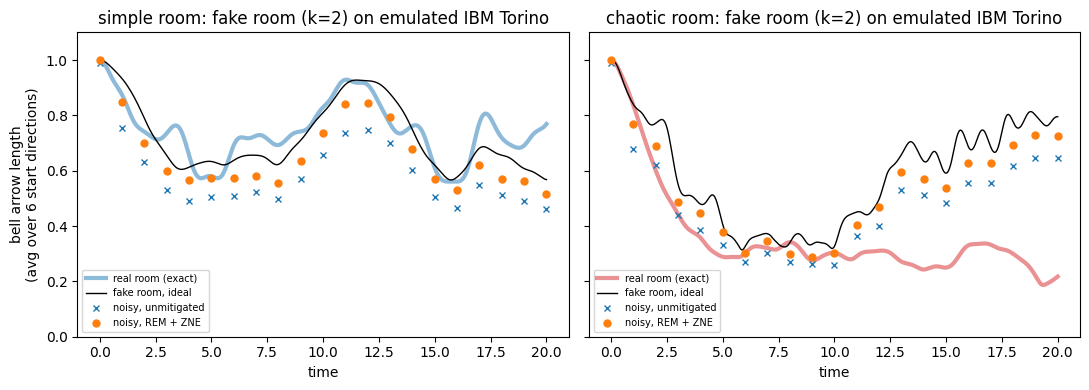

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ROOMS):
    r = hw[name]
    t_d = t_fine[t_fine <= 20]
    ax.plot(t_d, np.linalg.norm(data[name][:, : len(t_d)], axis=2).mean(axis=0),
            color=COLORS[name], lw=3, alpha=0.5, label="real room (exact)")
    model, theta, *_ = fits[name, 2]
    ax.plot(t_d, np.linalg.norm(model.predict(theta, t_d), axis=2).mean(axis=0), "k-", lw=1, label="fake room, ideal")
    for key, mk, lbl in (("raw", "x", "noisy, unmitigated"), ("zne", "o", "noisy, REM + ZNE")):
        ax.plot(HW_TIMES, np.linalg.norm(r[key], axis=2).mean(axis=0), mk, ms=5, label=lbl)
    ax.set(title=f"{name} room: fake room (k=2) on emulated IBM Torino", xlabel="time", ylim=(0, 1.1))
    ax.legend(fontsize=7, loc="lower left")
axes[0].set_ylabel("bell arrow length\n(avg over 6 start directions)")
plt.tight_layout()
plt.show()

**Reading the result.** Noise pulls the arrow towards the centre of the sphere: the unmitigated points sit *below* the
ideal fake-room curve because noise itself erases information. Readout mitigation removes the small measurement bias,
and ZNE removes most of the remaining gate-noise bias. What is left is close to the shot-noise floor. The emulated device
reproduces the trained model's predictions, including the echo/no-echo difference between the rooms.

| room | raw | REM | REM + ZNE |
|---|---|---|---|
| simple | 0.082 | 0.079 | **0.047** |
| chaotic | 0.067 | 0.065 | **0.041** |

*RMS error against the ideal fake room; shot-noise floor ≈ 0.011.* ZNE removes about 40% of the error. A side observation: in the chaotic room, unmitigated hardware noise pulls the false echo *down*, towards the real room. Noise acts like an uncontrolled leak, which is exactly the ingredient that the leaky-helper model of Section 10 learns in a controlled way.

**Main results**
1. A unitary quantum memory of $k=3$ helpers forecasts the integrable environment about **8× further** past its training
   data than the chaotic one (Section 9).
2. Classical models fail to forecast the coherent echoes of the integrable room; the unitary quantum model fails to
   forecast the chaotic room (false echoes). Each family has the wrong *inductive bias* for one of the two rooms (Section 10).
3. **Coherent quantum memory plus a small leak** (damped pseudomodes) has the right bias for both rooms: it is the best
   model in the chaotic room at every size tested, and close to the best in the integrable room (Section 10).
4. The trained model compiles to a fixed-depth circuit and survives realistic hardware noise once error mitigation is
   applied (Section 11).

**Future work:** leaky helpers on hardware via mid-circuit reset (collision models); $k \ge 4$; larger real rooms;
linking the forecast horizon to the scrambling rate (OTOCs); several random seeds and training windows.

## References
1. M. C. Bañuls, J. I. Cirac, M. B. Hastings, *Strong and weak thermalization of infinite nonintegrable quantum systems*, Phys. Rev. Lett. **106**, 050405 (2011).
2. M. Suzuki, *Generalized Trotter's formula and systematic approximants of exponential operators and inner derivations with applications to many-body problems*, Commun. Math. Phys. **51**, 183 (1976).
3. V. Oganesyan, D. A. Huse, *Localization of interacting fermions at high temperature*, Phys. Rev. B **75**, 155111 (2007).
4. Y. Y. Atas, E. Bogomolny, O. Giraud, G. Roux, *Distribution of the ratio of consecutive level spacings in random matrix ensembles*, Phys. Rev. Lett. **110**, 084101 (2013).
5. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, *Neural Ordinary Differential Equations*, NeurIPS (2018).
6. E. Dupont, A. Doucet, Y. W. Teh, *Augmented Neural ODEs*, NeurIPS (2019).
7. Y. Rubanova, R. T. Q. Chen, D. Duvenaud, *Latent ODEs for Irregularly-Sampled Time Series*, NeurIPS (2019).
8. B. M. Garraway, *Nonperturbative decay of an atomic system in a cavity*, Phys. Rev. A **55**, 2290 (1997).
9. D. Tamascelli, A. Smirne, S. F. Huelga, M. B. Plenio, *Nonperturbative treatment of non-Markovian dynamics of open quantum systems*, Phys. Rev. Lett. **120**, 030402 (2018).
10. H.-P. Breuer, E.-M. Laine, J. Piilo, *Measure for the degree of non-Markovian behavior of quantum processes in open systems*, Phys. Rev. Lett. **103**, 210401 (2009).
11. I. Najfeld, T. F. Havel, *Derivatives of the matrix exponential and their computation*, Adv. Appl. Math. **16**, 321 (1995).
12. K. Mitarai, M. Negoro, M. Kitagawa, K. Fujii, *Quantum circuit learning*, Phys. Rev. A **98**, 032309 (2018); M. Schuld, V. Bergholm, C. Gogolin, J. Izaac, N. Killoran, *Evaluating analytic gradients on quantum hardware*, Phys. Rev. A **99**, 032331 (2019).
13. R. H. Byrd, P. Lu, J. Nocedal, C. Zhu, *A limited memory algorithm for bound constrained optimization*, SIAM J. Sci. Comput. **16**, 1190 (1995).
14. A. Javadi-Abhari et al., *Quantum computing with Qiskit*, arXiv:2405.08810 (2024).
15. P. Virtanen et al., *SciPy 1.0: fundamental algorithms for scientific computing in Python*, Nat. Methods **17**, 261 (2020).
16. N. Wiebe, C. Granade, C. Ferrie, D. G. Cory, *Hamiltonian learning and certification using quantum resources*, Phys. Rev. Lett. **112**, 190501 (2014).
17. K. Fujii, K. Nakajima, *Harnessing disordered-ensemble quantum dynamics for machine learning*, Phys. Rev. Applied **8**, 024030 (2017).
18. F. Vatan, C. Williams, *Optimal quantum circuits for general two-qubit gates*, Phys. Rev. A **69**, 032315 (2004).
19. J. Pathak, B. Hunt, M. Girvan, Z. Lu, E. Ott, *Model-free prediction of large spatiotemporally chaotic systems from data: a reservoir computing approach*, Phys. Rev. Lett. **120**, 024102 (2018).
20. L. Ljung, *System Identification: Theory for the User*, 2nd ed., Prentice Hall (1999).
21. G. Lindblad, *On the generators of quantum dynamical semigroups*, Commun. Math. Phys. **48**, 119 (1976).
22. V. Gorini, A. Kossakowski, E. C. G. Sudarshan, *Completely positive dynamical semigroups of N-level systems*, J. Math. Phys. **17**, 821 (1976).
23. J. Bradbury et al., *JAX: composable transformations of Python+NumPy programs*, http://github.com/jax-ml/jax (2018).
24. S. Bravyi, S. Sheldon, A. Kandala, D. C. McKay, J. M. Gambetta, *Mitigating measurement errors in multiqubit experiments*, Phys. Rev. A **103**, 042605 (2021).
25. K. Temme, S. Bravyi, J. M. Gambetta, *Error mitigation for short-depth quantum circuits*, Phys. Rev. Lett. **119**, 180509 (2017).
26. T. Giurgica-Tiron, Y. Hindy, R. LaRose, A. Mari, W. J. Zeng, *Digital zero noise extrapolation for quantum error mitigation*, IEEE Int. Conf. on Quantum Computing and Engineering (QCE), 306 (2020).
27. J. J. Wallman, J. Emerson, *Noise tailoring for scalable quantum computation via randomized compiling*, Phys. Rev. A **94**, 052325 (2016).
28. E. van den Berg, Z. K. Minev, K. Temme, *Model-free readout-error mitigation for quantum expectation values*, Phys. Rev. A **105**, 032620 (2022).
29. L. Viola, E. Knill, S. Lloyd, *Dynamical decoupling of open quantum systems*, Phys. Rev. Lett. **82**, 2417 (1999).